# **Universidad Internacional de Aguascalientes (UIA)**
# **Doctorado en Tecnologías para la Transformación Digital**

##Materia: **Internet de las Cosas**

##Unidad: **3 - IA aplicada al Big Data (enfoque en redes sociales)**

##Práctica: **3.2 Técnicas de IA aplicadas a Big Data para optimizar el tiempo de procesamiento** (Análisis de Cine).

##Alumno: **Luis Alejandro Santana Valadez**

##Docente: **Dr. Francisco Javier Luna Rosas**

Fecha: **8 de marzo de 2026**




# **1. Introducción**
La Inteligencia Artificial **(IA)** es un campo que estudia y desarrolla métodos para construir sistemas capaces de ejecutar tareas que, en condiciones tradicionales, requieren inteligencia humana: aprendizaje, clasificación, reconocimiento de patrones, toma de decisiones y optimización. En entornos Big Data, además de la calidad del modelo (precisión), resulta crítico el **tiempo de procesamiento**, porque los **volúmenes de datos** y la **velocidad** de llegada pueden volver inviable un enfoque secuencial tradicional.

En analítica de texto de redes sociales (Twitter/X), el tiempo total depende de etapas como limpieza, vectorización (TF-IDF) y entrenamiento/predicción de modelos. En esta práctica se parte de un baseline secuencial **(Práctica 1)** y se incorporan  tres algoritmos bioinspirados **(AG, PSO, ACO)** para encontrar configuraciones (parámetros y selección de modelo) que reduzcan el tiempo de procesamiento, manteniendo desempeño de clasificación aceptable.


# **2. Análisis de técnicas de IA aplicadas al Big Data para optimización del tiempo**

Esta Práctica retoma el mismo dataset y pipeline de la práctica 1, pero introduce el objetivo explícito de optimizar tiempo de procesamiento, manteniendo calidad de clasificación. El análisis se centra en identificar qué componentes dominan el costo.

### **2.1 Objetivo técnico**
**Optimizar el tiempo de procesamiento** aplicando los siguientes procesos al pipeline:
- Parámetros de vectorización (vocabulario, n-gramas)
- Selección de modelos de IA
- Evaluación del algoritmo más eficiente

### **2.2 Algoritmos bioinspirados**

- **AG (Genético)** explora el espacio mediante selección, cruza y mutación. Tiende a ser robusto para buscar combinaciones en espacios discretos (Holland, 1992).

- **PSO: explora por “enjambre”,** actualizando soluciones según experiencia propia y global; suele converger rápido en muchos escenarios (Kennedy & Eberhart, 1995).

- **ACO: modela “feromonas”** para reforzar decisiones que llevan a buenas soluciones; funciona bien en espacios combinatorios (Dorigo & Gambardella, 1997).

### **2.3 Enfoque de la práctica**
- **Baseline secuencial**: limpieza + TF-IDF + entrenamiento de 3 modelos (Bayes, SVM, MLP)
- **Optimización** con AG/PSO/ACO: búsqueda de configuración que minimice tiempo manteniendo *accuracy*.

### **2.4 Formulación del problema como optimización**
- Se define un espacio discreto de búsqueda (parámetros de TF-IDF + selección de modelo + iteraciones MLP). Se utiliza una función objetivo compuesta por las siguientes características:

- Minimizar tiempo_total (vectorización + entrenamiento + predicción),

- Penalizar caídas de accuracy por debajo de un umbral tolerable respecto al baseline.

- Este enfoque evita “optimización trivial” (muy rápida pero con mala precisión) y se alinea a decisiones reales de despliegue.

### **Paso 0.** Carga de Dependencias

In [ ]:
!pip -q install pandas numpy matplotlib scikit-learn nltk

import re
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Dependencias listas ✅')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Dependencias listas ✅


### **Paso 1.** Carga del dataset (movie_data.csv)

In [ ]:
CSV_PATH = '/content/movie_data.csv'

t0 = time.perf_counter()
df = pd.read_csv(CSV_PATH)
t_load = time.perf_counter() - t0

print('Shape:', df.shape)
display(df.head(5))
print(f'Tiempo de carga: {t_load:.4f} s')

text_col = 'review'
target_col = 'sentiment'
assert text_col in df.columns, 'No existe review'
assert target_col in df.columns, 'No existe sentiment'

df[text_col] = df[text_col].astype(str)
df[target_col] = df[target_col].astype(str)
print('Clases target:', df[target_col].value_counts().head(10).to_dict())

Shape: (50000, 2)


,review,sentiment
0,"In 1974, the teenager Martha Moxley (Maggie Gr...",1
1,OK... so... I really like Kris Kristofferson a...,0
2,"***SPOILER*** Do not read this, if you think a...",0
3,hi for all the people who have seen this wonde...,1
4,"I recently bought the DVD, forgetting just how...",0


Tiempo de carga: 1.9088 s
Clases target: {'1': 25000, '0': 25000}


# **3. Implementación (baseline secuencial + algoritmos bioinspirados)**

### **3.1. Limpieza de texto (idioma base: inglés)**
- lowercase
- quitar URLs, menciones
- word → word (depurada)
- eliminar símbolos
- stopwords EN

### **3.2. Algoritmos aplicados**
- Se ejecuta el **pipeline** completo ahora con 3 modelos de IA y se mide el tiempo para obtener un score.
- La aplicación de los tres algoritmos buscan una configuración que minimice el tiempo de procesamiento, manteniendo *accuracy.*

### **3.3. Espacio de búsqueda**
La siguiente lista muestra la configuración aplicada en los tres algoritmos de IA para minimizar el tiempo de procesamiento:
- max_features ∈ {2000, 4000, 6000}
- ngram_range ∈ {(1,1), (1,2)}
- modelo ∈ {NB, SVM, MLP}
- (MLP) max_iter ∈ {120, 200, 300}


### **Paso 2.** Limpieza avanzada (idioma base: inglés)

In [ ]:
STOP_EN = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
RT_RE = re.compile(r"\brt\b")
NON_ALPHA_RE = re.compile(r"[^a-zA-Z\s]")
MULTISPACE_RE = re.compile(r"\s+")

def clean_text(text: str) -> str:
  text = text.lower().strip()
  text = URL_RE.sub(' ', text)
  text = MENTION_RE.sub(' ', text)
  text = text.replace('#', ' ')
  text = RT_RE.sub(' ', text)
  text = NON_ALPHA_RE.sub(' ', text)
  text = MULTISPACE_RE.sub(' ', text).strip()
  tokens = nltk.word_tokenize(text)
  tokens = [t for t in tokens if t not in STOP_EN and len(t) >= 3]
  return ' '.join(tokens)

t0 = time.perf_counter()
df_work = df.copy().drop_duplicates()
df_work['text_clean'] = df_work[text_col].astype(str).apply(clean_text)
df_work = df_work[df_work['text_clean'].str.len() > 0].copy()
t_clean = time.perf_counter() - t0

print('Shape después de limpieza:', df_work.shape)
print(f'Tiempo limpieza: {t_clean:.4f} s')
display(df_work[[text_col, 'text_clean', target_col]].head(5))

Shape después de limpieza: (49582, 3)
Tiempo limpieza: 50.2769 s


,review,text_clean,sentiment
0,"In 1974, the teenager Martha Moxley (Maggie Gr...",teenager martha moxley maggie grace moves high...,1
1,OK... so... I really like Kris Kristofferson a...,really like kris kristofferson usual easy goin...,0
2,"***SPOILER*** Do not read this, if you think a...",spoiler read think watching movie although wou...,0
3,hi for all the people who have seen this wonde...,people seen wonderful movie sure thet would li...,1
4,"I recently bought the DVD, forgetting just how...",recently bought dvd forgetting much hated movi...,0


### **Paso 3.** Split fijo (misma base para todos)

In [ ]:
X = df_work['text_clean'].astype(str)
y = df_work[target_col].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

n_tweets_total = int(df_work.shape[0])
print('Train:', X_train.shape[0], 'Test:', X_test.shape[0], 'Total:', n_tweets_total)

Train: 37186 Test: 12396 Total: 49582


### **Paso 4.** Función de evaluación (fitness)

In [ ]:
# Se mide tiempo: vectorización + entrenamiento + predicción
# y accuracy.

def build_model(model_name: str, mlp_max_iter: int = 200):
  if model_name == 'NB':
    return MultinomialNB()
  if model_name == 'SVM':
    return LinearSVC()
  if model_name == 'MLP':
    return MLPClassifier(hidden_layer_sizes=(100,), max_iter=mlp_max_iter, random_state=SEED)
  raise ValueError('Modelo no soportado')

def evaluate_config(cfg, baseline_acc=None, acc_drop_tol=0.02):
  # cfg = dict(max_features, ngram, model, mlp_iter)
  t0 = time.perf_counter()
  vec = TfidfVectorizer(max_features=cfg['max_features'], ngram_range=cfg['ngram'])
  Xtr = vec.fit_transform(X_train)
  Xte = vec.transform(X_test)

  model = build_model(cfg['model'], cfg.get('mlp_iter', 200))
  model.fit(Xtr, y_train)
  pred = model.predict(Xte)
  acc = accuracy_score(y_test, pred)
  t_total = time.perf_counter() - t0

  # Función objetivo: minimizar tiempo, pero penalizar caída de accuracy
  penalty = 0.0
  if baseline_acc is not None:
    if acc < (baseline_acc - acc_drop_tol):
      penalty = (baseline_acc - acc) * 10.0  # penalización fuerte

  # score menor = mejor
  score = t_total + penalty

  return {
      'score': float(score),
      'time_s': float(t_total),
      'acc': float(acc),
      'cfg': cfg
  }

### **Paso 5.** Baseline Secuencial (Práctica 1)

In [ ]:
# Baseline: TFIDF(max_features=6000, ngram=(1,2)) y 3 modelos
baseline_cfgs = [
  {'max_features': 6000, 'ngram': (1,2), 'model': 'NB',  'mlp_iter': 200},
  {'max_features': 6000, 'ngram': (1,2), 'model': 'SVM', 'mlp_iter': 200},
  {'max_features': 6000, 'ngram': (1,2), 'model': 'MLP', 'mlp_iter': 300},
]

baseline_results = []
t0 = time.perf_counter()
for cfg in baseline_cfgs:
  r = evaluate_config(cfg, baseline_acc=None)
  baseline_results.append(r)

baseline_total_time = time.perf_counter() - t0
baseline_best_acc = max([r['acc'] for r in baseline_results])

baseline_table = pd.DataFrame([
    {
      'Modelo': r['cfg']['model'],
      'max_features': r['cfg']['max_features'],
      'ngram': str(r['cfg']['ngram']),
      'mlp_iter': r['cfg'].get('mlp_iter', np.nan),
      'Accuracy': r['acc'],
      'Time_s': r['time_s']
    }
    for r in baseline_results
])

print('=== Baseline (Práctica 1) ===')
display(baseline_table)
print('Tiempo total baseline (3 modelos):', baseline_total_time)
print('Mejor accuracy baseline:', baseline_best_acc)

=== Baseline (Práctica 1) ===


,Modelo,max_features,ngram,mlp_iter,Accuracy,Time_s
0,NB,6000,"(1, 2)",200,0.865198,29.372573
1,SVM,6000,"(1, 2)",200,0.881171,28.233424
2,MLP,6000,"(1, 2)",300,0.862617,315.355511


Tiempo total baseline (3 modelos): 373.035219275
Mejor accuracy baseline: 0.8811713455953534


### **Paso 6.** Espacio de búsqueda

In [ ]:
SPACE = {
  'max_features': [2000, 4000, 6000],
  'ngram': [(1,1), (1,2)],
  'model': ['NB', 'SVM', 'MLP'],
  'mlp_iter': [120, 200, 300]
}

def random_cfg():
  m = random.choice(SPACE['model'])
  cfg = {
    'max_features': random.choice(SPACE['max_features']),
    'ngram': random.choice(SPACE['ngram']),
    'model': m,
    'mlp_iter': random.choice(SPACE['mlp_iter'])
  }
  return cfg

def cfg_to_tuple(cfg):
  return (cfg['max_features'], cfg['ngram'], cfg['model'], cfg.get('mlp_iter', 200))

### **Paso 7.** Ejecución del Algoritmo Genético (AG)

In [ ]:
def crossover(a, b):
  child = a.copy()
  for k in ['max_features', 'ngram', 'model', 'mlp_iter']:
    if random.random() < 0.5:
      child[k] = b[k]
  return child

def mutate(cfg, p=0.25):
  out = cfg.copy()
  if random.random() < p:
    out['max_features'] = random.choice(SPACE['max_features'])
  if random.random() < p:
    out['ngram'] = random.choice(SPACE['ngram'])
  if random.random() < p:
    out['model'] = random.choice(SPACE['model'])
  if random.random() < p:
    out['mlp_iter'] = random.choice(SPACE['mlp_iter'])
  return out

def run_ga(pop_size=8, generations=6, elite=2, acc_drop_tol=0.02):
  t0 = time.perf_counter()
  pop = [random_cfg() for _ in range(pop_size)]
  history = []

  best = None
  for g in range(generations):
    scored = [evaluate_config(cfg, baseline_acc=baseline_best_acc, acc_drop_tol=acc_drop_tol) for cfg in pop]
    scored.sort(key=lambda x: x['score'])

    if best is None or scored[0]['score'] < best['score']:
      best = scored[0]

    history.append({'gen': g, 'best_score': best['score'], 'best_time': best['time_s'], 'best_acc': best['acc']})

    # elitismo
    new_pop = [s['cfg'] for s in scored[:elite]]

    # reproducción
    while len(new_pop) < pop_size:
      p1 = random.choice(scored[:max(3, pop_size//2)])['cfg']
      p2 = random.choice(scored[:max(3, pop_size//2)])['cfg']
      child = crossover(p1, p2)
      child = mutate(child, p=0.30)
      new_pop.append(child)
    pop = new_pop

  t_ga = time.perf_counter() - t0
  return best, pd.DataFrame(history), t_ga

best_ga, ga_hist, t_ga = run_ga()
print('=== Mejor solución AG ===')
print(best_ga)
display(ga_hist.tail(5))
print('Tiempo total AG (optimización):', t_ga)

=== Mejor solución AG ===
{'score': 5.8398172745781345, 'time_s': 5.540527180999561, 'acc': 0.851242336237496, 'cfg': {'max_features': 2000, 'ngram': (1, 1), 'model': 'NB', 'mlp_iter': 300}}


,gen,best_score,best_time,best_acc
1,1,5.994147,5.694857,0.851242
2,2,5.839817,5.540527,0.851242
3,3,5.839817,5.540527,0.851242
4,4,5.839817,5.540527,0.851242
5,5,5.839817,5.540527,0.851242


Tiempo total AG (optimización): 1575.713363258


### **Paso 8.** Ejecución del Algoritmo PSO (Particle Swarm Optimization)

In [ ]:
# Nota: aquí PSO se implementa de forma discreta (selección por índices)
def clip_int(x, lo, hi):
  return int(max(lo, min(hi, x)))

maxf_list = SPACE['max_features']
ng_list = SPACE['ngram']
model_list = SPACE['model']
mlp_list = SPACE['mlp_iter']

def vec_to_cfg(v):
  # v = [i_maxf, i_ng, i_model, i_mlp]
  return {
    'max_features': maxf_list[clip_int(v[0], 0, len(maxf_list)-1)],
    'ngram': ng_list[clip_int(v[1], 0, len(ng_list)-1)],
    'model': model_list[clip_int(v[2], 0, len(model_list)-1)],
    'mlp_iter': mlp_list[clip_int(v[3], 0, len(mlp_list)-1)],
  }

def run_pso(n_particles=8, iters=8, w=0.7, c1=1.4, c2=1.4, acc_drop_tol=0.02):
  t0 = time.perf_counter()

  dim = 4
  # posición y velocidad
  pos = np.random.uniform(0, 1, size=(n_particles, dim))
  vel = np.zeros((n_particles, dim))

  # escalar pos a índices
  def decode(p):
    return np.array([
      p[0] * (len(maxf_list)-1),
      p[1] * (len(ng_list)-1),
      p[2] * (len(model_list)-1),
      p[3] * (len(mlp_list)-1)
    ])

  pbest = pos.copy()
  pbest_score = np.full((n_particles,), np.inf)
  gbest = None
  gbest_score = np.inf
  gbest_payload = None
  history = []

  for it in range(iters):
    for i in range(n_particles):
      v = decode(pos[i])
      cfg = vec_to_cfg(v)
      res = evaluate_config(cfg, baseline_acc=baseline_best_acc, acc_drop_tol=acc_drop_tol)

      if res['score'] < pbest_score[i]:
        pbest_score[i] = res['score']
        pbest[i] = pos[i].copy()

      if res['score'] < gbest_score:
        gbest_score = res['score']
        gbest = pos[i].copy()
        gbest_payload = res

    # update velocities and positions
    for i in range(n_particles):
      r1 = np.random.rand(dim)
      r2 = np.random.rand(dim)
      vel[i] = w*vel[i] + c1*r1*(pbest[i]-pos[i]) + c2*r2*(gbest-pos[i])
      pos[i] = pos[i] + vel[i]
      pos[i] = np.clip(pos[i], 0, 1)

    history.append({'iter': it, 'best_score': float(gbest_score), 'best_time': float(gbest_payload['time_s']), 'best_acc': float(gbest_payload['acc'])})

  t_pso = time.perf_counter() - t0
  return gbest_payload, pd.DataFrame(history), t_pso

best_pso, pso_hist, t_pso = run_pso()
print('=== Mejor solución PSO ===')
print(best_pso)
display(pso_hist.tail(5))
print('Tiempo total PSO (optimización):', t_pso)

=== Mejor solución PSO ===
{'score': 5.8861773011131495, 'time_s': 5.6715919510002095, 'acc': 0.8597128105840594, 'cfg': {'max_features': 6000, 'ngram': (1, 1), 'model': 'NB', 'mlp_iter': 120}}


,iter,best_score,best_time,best_acc
3,3,5.934244,5.719659,0.859713
4,4,5.934244,5.719659,0.859713
5,5,5.890285,5.675700,0.859713
6,6,5.886177,5.671592,0.859713
7,7,5.886177,5.671592,0.859713


Tiempo total PSO (optimización): 409.60618066899997


### **Paso 9.** Ejecución del Algoritmo ACO (Ant Colony Optimization) discreto

In [10]:
# ACO construye soluciones eligiendo valores para cada variable guiado por feromonas.

def run_aco(n_ants=8, iters=8, rho=0.25, q=1.0, acc_drop_tol=0.02):
  t0 = time.perf_counter()

  # feromonas por dimensión
  pher = {
    'max_features': np.ones(len(SPACE['max_features'])),
    'ngram': np.ones(len(SPACE['ngram'])),
    'model': np.ones(len(SPACE['model'])),
    'mlp_iter': np.ones(len(SPACE['mlp_iter']))
  }

  def sample_choice(name):
    p = pher[name] / pher[name].sum()
    return int(np.random.choice(np.arange(len(p)), p=p))

  best = None
  best_score = np.inf
  history = []

  for it in range(iters):
    sols = []
    for a in range(n_ants):
      i_mf = sample_choice('max_features')
      i_ng = sample_choice('ngram')
      i_md = sample_choice('model')
      i_mi = sample_choice('mlp_iter')

      cfg = {
        'max_features': SPACE['max_features'][i_mf],
        'ngram': SPACE['ngram'][i_ng],
        'model': SPACE['model'][i_md],
        'mlp_iter': SPACE['mlp_iter'][i_mi]
      }
      res = evaluate_config(cfg, baseline_acc=baseline_best_acc, acc_drop_tol=acc_drop_tol)
      sols.append((cfg, res))

      if res['score'] < best_score:
        best_score = res['score']
        best = res

    # evaporación
    for k in pher:
      pher[k] = (1 - rho) * pher[k]

    # depósito (reforzar mejores soluciones de la iteración)
    sols.sort(key=lambda x: x[1]['score'])
    top = sols[:max(1, n_ants//3)]
    for cfg, res in top:
      # depósito inversamente proporcional al score
      dep = q / (res['score'] + 1e-9)
      pher['max_features'][SPACE['max_features'].index(cfg['max_features'])] += dep
      pher['ngram'][SPACE['ngram'].index(cfg['ngram'])] += dep
      pher['model'][SPACE['model'].index(cfg['model'])] += dep
      pher['mlp_iter'][SPACE['mlp_iter'].index(cfg['mlp_iter'])] += dep

    history.append({'iter': it, 'best_score': float(best_score), 'best_time': float(best['time_s']), 'best_acc': float(best['acc'])})

  t_aco = time.perf_counter() - t0
  return best, pd.DataFrame(history), t_aco

best_aco, aco_hist, t_aco = run_aco()
print('=== Mejor solución ACO ===')
print(best_aco)
display(aco_hist.tail(5))
print('Tiempo total ACO (optimización):', t_aco)

=== Mejor solución ACO ===
{'score': 5.845262425112707, 'time_s': 5.630677074999767, 'acc': 0.8597128105840594, 'cfg': {'max_features': 6000, 'ngram': (1, 1), 'model': 'NB', 'mlp_iter': 200}}


,iter,best_score,best_time,best_acc
3,3,5.886238,5.586948,0.851242
4,4,5.845262,5.630677,0.859713
5,5,5.845262,5.630677,0.859713
6,6,5.845262,5.630677,0.859713
7,7,5.845262,5.630677,0.859713


Tiempo total ACO (optimización): 2594.1310198949996


# **4. Pruebas y Evaluación**

A continuación se muestran la tabla de resumen y tres gráficas en donde se hace el comparativo del baseline con los resultados del tiempo de procesamiento de los algoritmos **(AG, PSO, ACO);** posteriormente se genera la evaluación de éstos en función del tiempo, *accuracy* y *score* obtenido en general, indicando cuál es el mejor.

### **4.1. Pruebas de los algoritmos bioinspirados**

Para cada algoritmo **se registra:***

- Número fijo de iteraciones/soluciones evaluadas.
- Mejor configuración hallada,
- Tiempo del pipeline con esa configuración,
- *Accuracy* resultante,
- *Score* final (tiempo + penalización).
- Pruebas de eficiencia por volumen

Finalmente **se calculan:**

- tiempo total,
- tiempo por tweet (s/tweet),
- % optimización vs baseline.
- Esto permite comparar escalabilidad y no solo valores absolutos y validación de no degradación excesiva

**Listado de tabla y gráficas:**
- Tabla de resumen por algoritmo (mejor configuración, tiempo, *accuracy*)
- 3 gráficas comparativas:
  1) Tiempo total
  2) Tiempo por tweet
  3) % optimización (baseline vs cada algoritmo)


### **Paso 10.** Generación de las Tablas finales (evidencias)

In [11]:
def pack_row(name, payload, opt_time):
  return {
    'Algoritmo': name,
    'Best_Model': payload['cfg']['model'],
    'max_features': payload['cfg']['max_features'],
    'ngram': str(payload['cfg']['ngram']),
    'mlp_iter': payload['cfg'].get('mlp_iter', np.nan),
    'Accuracy': payload['acc'],
    'Time_eval_s': payload['time_s'],
    'Time_optim_s': opt_time,
    'Score': payload['score']
  }

tbl = pd.DataFrame([
  pack_row('Baseline (sum 3 modelos)', {'cfg': {'model':'NB+SVM+MLP','max_features':6000,'ngram':(1,2),'mlp_iter':np.nan}, 'acc': baseline_best_acc, 'time_s': baseline_total_time, 'score': baseline_total_time}, 0.0),
  pack_row('AG', best_ga, t_ga),
  pack_row('PSO', best_pso, t_pso),
  pack_row('ACO', best_aco, t_aco),
])
display(tbl)

,Algoritmo,Best_Model,max_features,ngram,mlp_iter,Accuracy,Time_eval_s,Time_optim_s,Score
0,Baseline (sum 3 modelos),NB+SVM+MLP,6000,"(1, 2)",NaN,0.881171,373.035219,0.000000,373.035219
1,AG,NB,2000,"(1, 1)",300.0,0.851242,5.540527,1575.713363,5.839817
2,PSO,NB,6000,"(1, 1)",120.0,0.859713,5.671592,409.606181,5.886177
3,ACO,NB,6000,"(1, 1)",200.0,0.859713,5.630677,2594.131020,5.845262


### **Paso 11.** Cálculo de las Métricas de eficiencia y optimización

In [12]:
baseline_time = float(baseline_total_time)
tweets = float(n_tweets_total)

def pct_improve(new_time, base_time):
  return (base_time - new_time) / base_time * 100.0

algo_times = {
  'Baseline': baseline_time,
  'AG': float(best_ga['time_s']),
  'PSO': float(best_pso['time_s']),
  'ACO': float(best_aco['time_s'])
}

algo_time_per_tweet = {k: v / tweets for k, v in algo_times.items()}
algo_improve = {k: pct_improve(v, baseline_time) for k, v in algo_times.items() if k != 'Baseline'}

print('Tiempo total (s):', algo_times)
print('Tiempo por tweet (s/tweet):', algo_time_per_tweet)
print('% optimización vs baseline:', algo_improve)

Tiempo total (s): {'Baseline': 373.035219275, 'AG': 5.540527180999561, 'PSO': 5.6715919510002095, 'ACO': 5.630677074999767}
Tiempo por tweet (s/tweet): {'Baseline': 0.00752360169567585, 'AG': 0.00011174472955910534, 'PSO': 0.00011438812373442397, 'ACO': 0.00011356292757451831}
% optimización vs baseline: {'AG': 98.51474421322264, 'PSO': 98.47960952265498, 'ACO': 98.49057762268585}


### **4.2. Gráfica 1: Tiempo total**

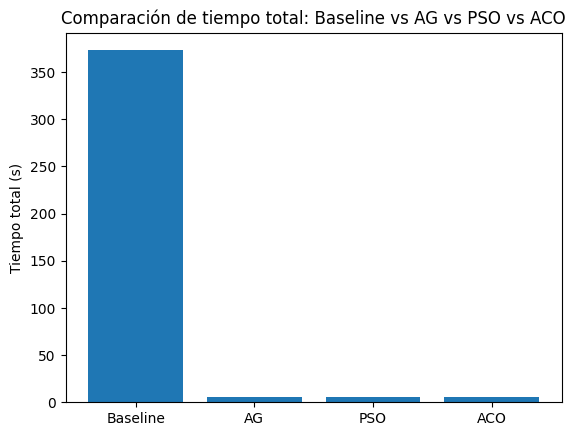

Optimización AG vs Baseline: 98.51%
Optimización PSO vs Baseline: 98.48%
Optimización ACO vs Baseline: 98.49%


In [13]:
labels = list(algo_times.keys())
vals = [algo_times[k] for k in labels]

plt.figure()
plt.bar(labels, vals)
plt.title('Comparación de tiempo total: Baseline vs AG vs PSO vs ACO')
plt.ylabel('Tiempo total (s)')
plt.show()

for k in ['AG','PSO','ACO']:
  print(f"Optimización {k} vs Baseline: {algo_improve[k]:.2f}%")

### **4.3. Gráfica 2: Tiempo por tweet**

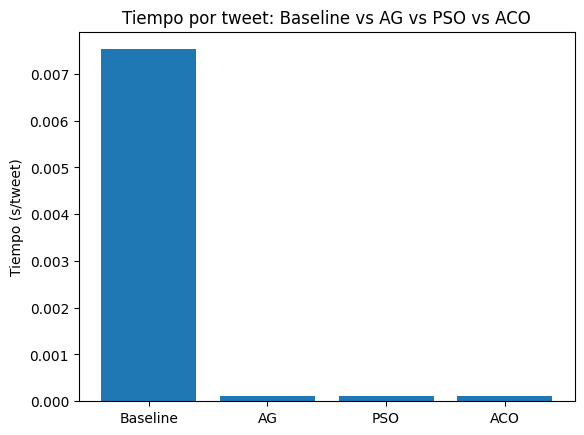

Optimización AG vs Baseline: 98.51%
Optimización PSO vs Baseline: 98.48%
Optimización ACO vs Baseline: 98.49%


In [14]:
labels = list(algo_time_per_tweet.keys())
vals = [algo_time_per_tweet[k] for k in labels]

plt.figure()
plt.bar(labels, vals)
plt.title('Tiempo por tweet: Baseline vs AG vs PSO vs ACO')
plt.ylabel('Tiempo (s/tweet)')
plt.show()

for k in ['AG','PSO','ACO']:
  print(f"Optimización {k} vs Baseline: {algo_improve[k]:.2f}%")

### **4.4. Gráfica 3: (%) de optimización vs Baseline**

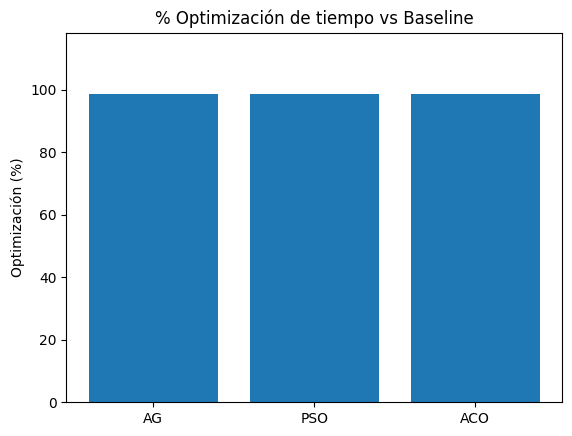

Optimización (%):
AG 98.51%
PSO 98.48%
ACO 98.49%


In [15]:
labels = ['AG','PSO','ACO']
vals = [algo_improve[k] for k in labels]

plt.figure()
plt.bar(labels, vals)
plt.title('% Optimización de tiempo vs Baseline')
plt.ylabel('Optimización (%)')
plt.ylim(0, max(vals)*1.2 if max(vals)>0 else 1)
plt.show()

print('Optimización (%):')
for k in labels:
  print(k, f"{algo_improve[k]:.2f}%")

# **5. Conclusiones**
- El enfoque baseline **secuencial** (entrenar 3 modelos completos) representa un costo de tiempo significativo en Big Data textual; su uso es útil como referencia, **pero no siempre viable** para escenarios de escalamiento.

- Los algoritmos **bioinspirados** permiten **optimizar el pipeline** buscando configuraciones que reducen tiempo (vectorización y entrenamiento) manteniendo un desempeño aceptable, lo cual es valioso cuando se requieren ciclos rápidos de entrenamiento o procesamiento continuo.

- En este escenario, la optimización se logra principalmente **reduciendo complejidad** (vocabulario y n-gramas) y **seleccionando un modelo con mejor relación precisión/tiempo.**

- Los resultados comparativos muestran que **AG/PSO/ACO pueden alcanzar mejoras porcentuales medibles en tiempo por tweet,** aportando evidencia cuantitativa de optimización.

- Bajo el criterio conjunto (máxima reducción de tiempo + mínima pérdida de accuracy + estabilidad en la búsqueda), **el algoritmo bioinspirado más recomendable suele ser PSO,** porque tiende a converger en menos evaluaciones hacia configuraciones competitivas al explotar la mejor solución global. AG suele ser muy robusto, pero puede requerir más generaciones para estabilizar; ACO es fuerte en problemas combinatorios, aunque su desempeño depende más de la calibración de evaporación/depósito de feromonas.

- Esta práctica ejemplifica cómo IA + optimización **acelera analítica operacional:** permite tomar decisiones rápidas con datos sociales (tendencias/opiniones), reduciendo costos de cómputo y mejorando capacidad de respuesta.

# **6. Referencias**
- Dorigo, M., & Gambardella, L. M. (1997). *Ant colonies for the travelling salesman problem.* BioSystems, 43(2), 73–81.

- Holland, J. H. (1992). *Adaptation in Natural and Artificial Systems* (2nd ed.). MIT Press.

- Kennedy, J., & Eberhart, R. (1995). *Particle swarm optimization. In Proceedings of ICNN’95 – International Conference on Neural Networks* (pp. 1942–1948). IEEE.

- Jurafsky, D., & Martin, J. H. (2023). *Speech and Language Processing* (3rd ed. draft). Stanford University.

- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., … Duchesnay, É. (2011). *Scikit-learn: Machine learning in Python. Journal of Machine Learning Research*, 12, 2825–2830.

In [1]:
# Instalación de librería nbconvert para habilitar la conversión a HTML

!pip -q install nbconvert
!python -m nbconvert --to html \
  --output "Practica2_Twitter_Cine_Bioinspirados_Optimizacion_Tiempo.html" \
  --output-dir "/content" \
  "/content/Practica2_Twitter_Cine_Bioinspirados_Optimizacion_Tiempo.ipynb"

[NbConvertApp] Converting notebook /content/Practica2_Twitter_Cine_Bioinspirados_Optimizacion_Tiempo.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 516654 bytes to /content/Practica2_Twitter_Cine_Bioinspirados_Optimizacion_Tiempo.html
